In [1]:
# Basic set of Python Data Analysis
import numpy as np
import pandas as pd

## for plot by matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import itertools
from cycler import cycler
import seaborn as sns

# for plot by matplotlib
sns.set(font="Serif", font_scale=2.0,
        rc={'figure.figsize': (10, 10),
            'lines.markersize': 15,
            "animation.embed_limit": 100})
sns.mpl.rc("axes", prop_cycle
           =cycler('color', ['#E24A33', '#348ABD', '#988ED5',
                             '#777777', '#FBC15E', '#8EBA42',
                             '#FFB5B8']))
sns.set_style('darkgrid', {'axes.facecolor': "0.8"})

# for markers
marker = itertools.cycle(('o', 'v', '^', 'D', '+', 'X', '<', '>'))
colors = itertools.cycle(('#E24A33', '#348ABD', '#988ED5', '#777777',
                          '#FBC15E', '#8EBA42', '#FFB5B8'))

## for machine learning with scikit learn
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


## don't show warning
import warnings
warnings.filterwarnings('ignore')

# import the Escal Tools
import os, sys
sys.path.append(os.path.expanduser("toolkits"))

In [2]:
%load_ext autoreload
%autoreload 2
import basicTools as bt
from Etranform import Efft as et
from mapTools import encoder as mt

# Parameters

In [3]:
## the data directory
datadir = os.path.realpath("data")
fname = "375"
filePref = f"{datadir}/{fname}"
print("The analysis will do for: \n", filePref)

## set the feature
feature = "dih"  #dih or dist

## The data per frames
skip = 1
imax = 100001

### similar metrix
similar = bt.dist.cosin

### smooth
step    = 100
width   = 200
seg2vec = bt.segment.mean

### evalute method
evalute = bt.evalute.cluster

The analysis will do for: 
 /home/ghzuo/project/Simulation/EscalNet/data/375


# The Input Data

## Structure of Trajectory

In [4]:
## read data from file
X0 = bt.feature.dih2X(f"{filePref}-rama.xvg") if feature == "dih" \
        else bt.feature.dist2X(f"{filePref}-CaDist.xvg") 

## get max length
if imax == 0 or imax>len(X0):
    imax = len(X0) 

## resample the X0
X0 = X0.iloc[1:imax:skip,:].reset_index(drop=True)
X0 = np.array(X0)
print("The shape of X0 is: ", X0.shape)
Xx = (X0 - np.mean(X0, axis=0))/np.std(X0,axis=0)
print("The shape of Xx is: ", Xx.shape)

The shape of input dihedral is:  (800008, 3)
The shape of X0 is:  (100000, 32)
The shape of Xx is:  (100000, 32)


## Energy of Trajectory

In [5]:
## read the energy data
eng = pd.DataFrame(np.loadtxt(f"{filePref}-potential.xvg", comments=["@","#"],
                             dtype = {'names': ('time', 'energy'), 
                                     'formats': ('f', 'f')}))

### output the data info
print("The shape of Raw Energy is: ", eng.shape)
eng = eng.iloc[1:imax:skip]

### base frequence in MHz
## 1000,000 for M and P, and 2 for even extension
ufreq = 500000/eng.loc[len(eng)-1, "time"]
print("The base frequence is {:.4f} MHz".format(ufreq))

E0 = np.array(eng['energy'])
print("The shape of Energy is: ", E0.shape)

The shape of Raw Energy is:  (100001, 2)
The base frequence is 0.5000 MHz
The shape of Energy is:  (100000,)


## RMSD from Native Structure

In [6]:
rms = np.loadtxt(f"{filePref}-CaRMS.xvg", comments=["@","#"],
                 dtype = {'names': ('time', 'rms'), 
                          'formats': ('f', 'f')})
rms = rms[1:imax:skip]
print("The shape of RMS is: ", rms.shape)

The shape of RMS is:  (100000,)


Text(0.5, 0, 'RMSD (nm)')

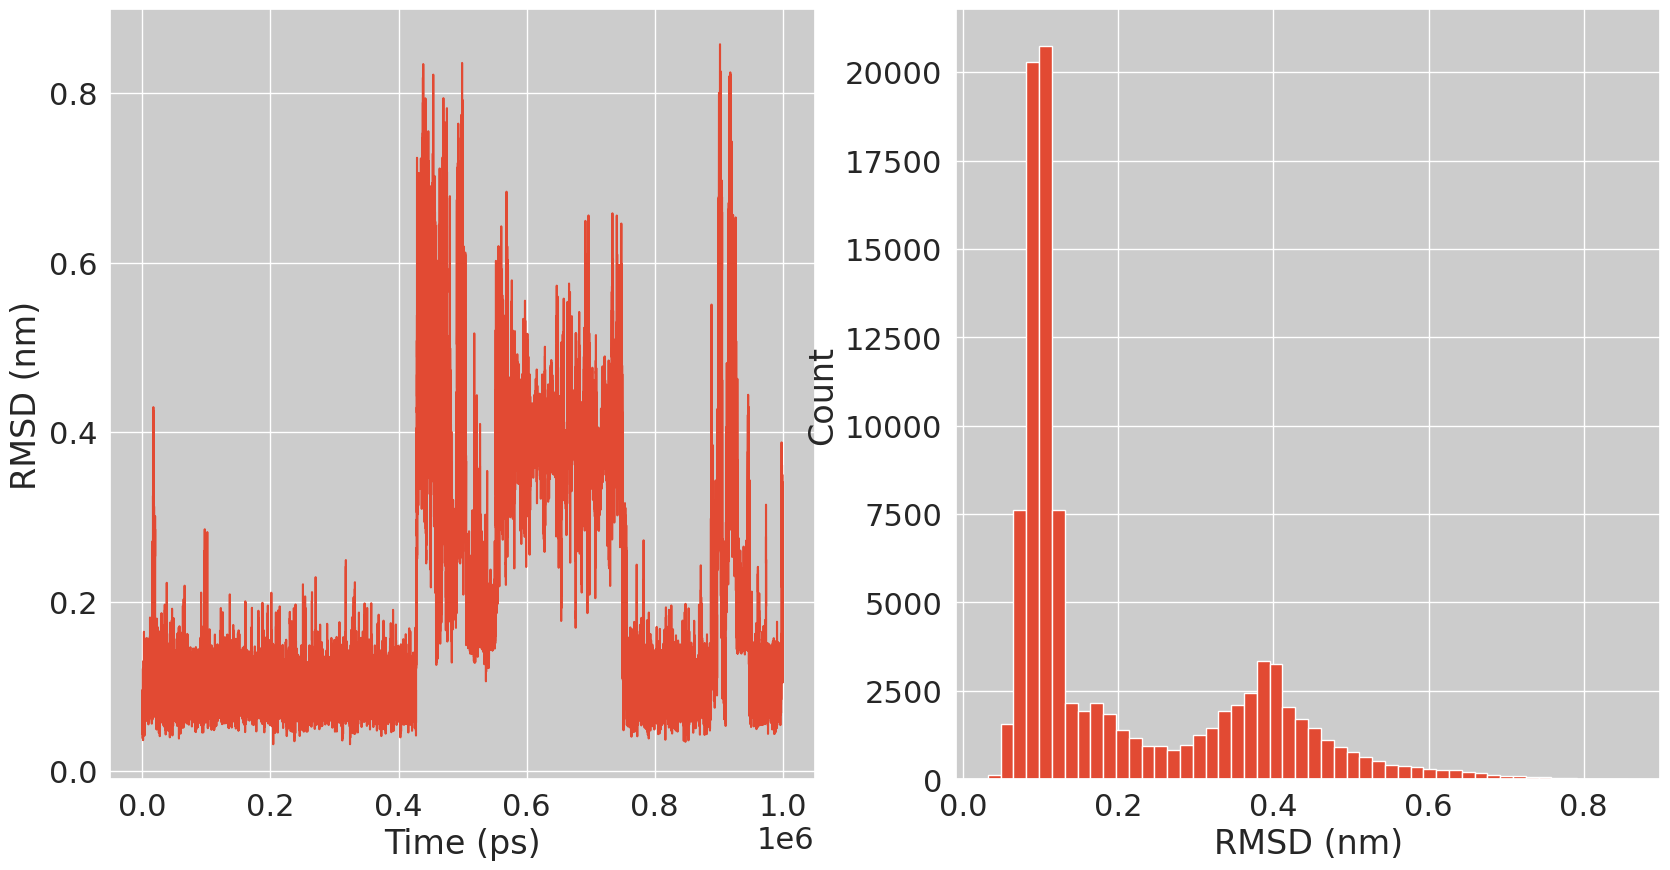

In [7]:
plt.figure(12,figsize=(20,10))
ax = plt.subplot(121)
ax.plot(rms['time'], rms['rms'])
plt.xlabel("Time (ps)")
plt.ylabel("RMSD (nm)")
ax = plt.subplot(122)
hist = ax.hist(rms["rms"], bins=50)
plt.ylabel("Count")
plt.xlabel("RMSD (nm)")

# Build and Pre-Train Network

In [8]:
## do FFT rescaling
efft = et(Xx, E0, base=False)

In [9]:
# set the network
nInput = X0.shape[1]
net = mt.MLP3L(nInput, nHidden=32)
#net = mt.LR(nInput)
#net = nn.Sequential(OrderedDict([('features',nn.Linear(nInput, 1))]))
print(net)

MLP3L(
  (input): Linear(in_features=32, out_features=32, bias=True)
  (actI): ELU(alpha=1.0)
  (hidden): Linear(in_features=32, out_features=32, bias=True)
  (actH): ELU(alpha=1.0)
  (feature): Linear(in_features=32, out_features=32, bias=True)
  (actF): ELU(alpha=1.0)
  (output): Linear(in_features=32, out_features=1, bias=True)
)


In [10]:
## set mapping method
xmap = mt.EncoderNet(net, efft, batch_size=32)

# Score of Kappa

In [11]:
## get the score
xmap.preTrain(n_epochs=5)
qmc = xmap.score(kmax=50, kmin=2, n_epochs=2)

Validate for PreTrain (kappa=2): 0.48184571242729163 0.7678247094154358
Validate for Score (kappa=2.0): 0.4843487886289442 0.7654062509536743
Validate for Score (kappa=3.0): 0.6929541464796806 0.5198145508766174
Validate for Score (kappa=4.0): 0.8478041313312351 0.2812281548976898
Validate for Score (kappa=5.0): 0.8340126586692077 0.30442288517951965
Validate for Score (kappa=6.0): 0.8128324158783079 0.33930346369743347
Validate for Score (kappa=7.0): 0.7957345431028378 0.3668065369129181
Validate for Score (kappa=8.0): 0.7949167574781046 0.3681073486804962
Validate for Score (kappa=9.0): 0.8137339611787461 0.3378370404243469
Validate for Score (kappa=10.0): 0.824945554237171 0.3194648325443268
Validate for Score (kappa=11.0): 0.8580675583220118 0.2637200653553009
Validate for Score (kappa=12.0): 0.8489231012596729 0.2793295681476593
Validate for Score (kappa=13.0): 0.8411661958542603 0.29243943095207214
Validate for Score (kappa=14.0): 0.8543093589285704 0.27015551924705505
Validate f

Text(28.7, 0.8520697095953614, '#24 (11.5 MHz)\nQMC = 0.89')

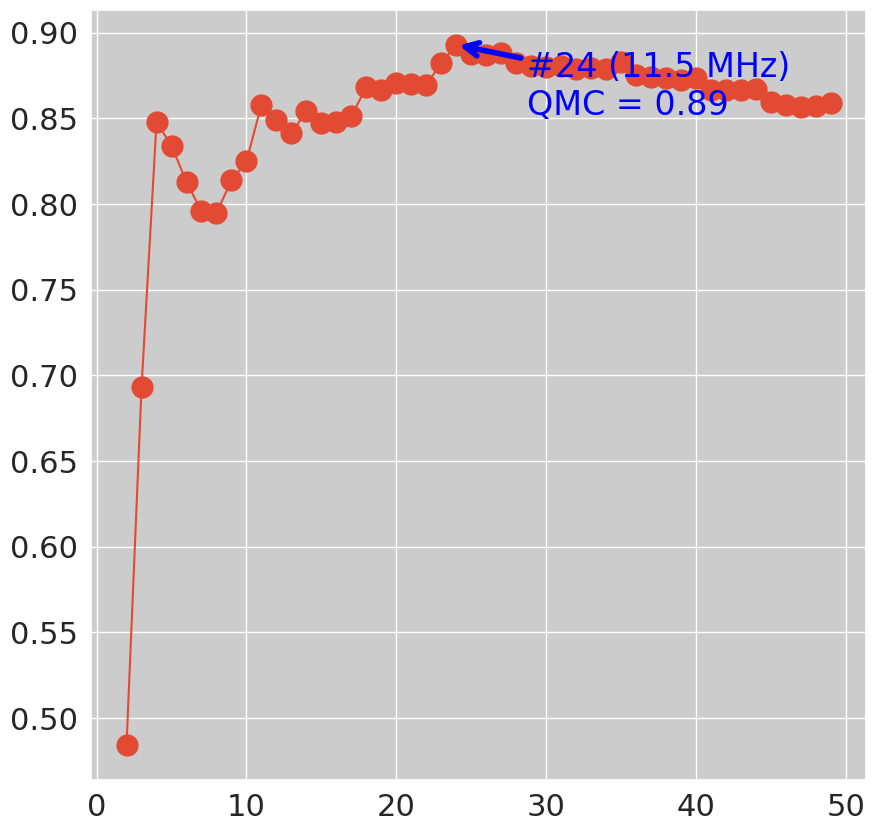

In [12]:
## plot the multiple correlation coefficient
plt.plot(qmc['list'][:,0],qmc['list'][:,1], marker="o")

## annotate the peak value
xy     = (qmc['KappaMax'], qmc['qmcMax'])
offset = 0.1 * (np.max(qmc['list'], axis=0)-np.min(qmc['list'],axis=0))
xytxt  = [xy[0] + offset[0], xy[1] - offset[1]]
plt.annotate("#{:d} ({:.1f} MHz)\nQMC = {:.2f}"
            .format(int(xy[0]), (xy[0]-1)*ufreq, xy[1]), 
            xy=xy, xytext=xytxt, color='blue', 
            arrowprops=dict(arrowstyle="->", color='blue', lw=4))

# Scaling of Selected Kappa

In [13]:
kappa = qmc['KappaMax']
rescl = xmap.scale(kappa, n_epochs=10)

Validate for Scaling (kappa=24.0): 0.8948857050779047 0.19917957484722137


## Weight of Features

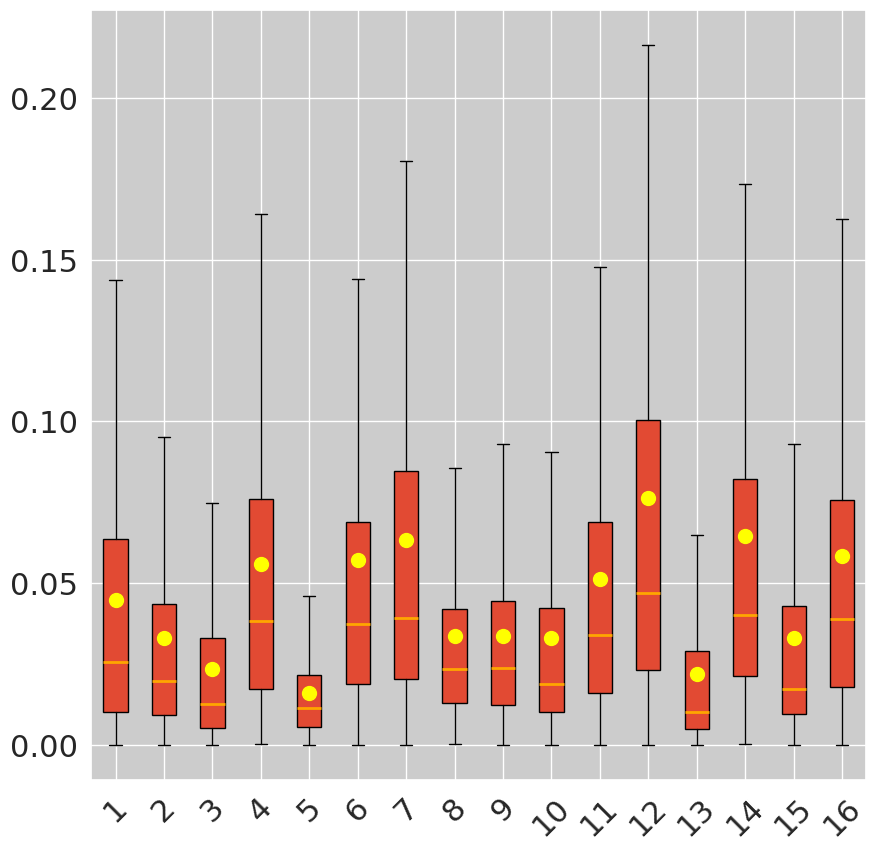

In [14]:
if net.__name__ == "LR":
    bt.plot.coefplot(bt.feature.dihCombind(rescl['A']) if feature == "dih" else rescl['A'])
else:
    sal = xmap.get_saliency()
    if feature == 'dih':
        sal = bt.feature.dihCombind(sal)
    bt.plot.saliplot(sal.T)

## Effective Energy

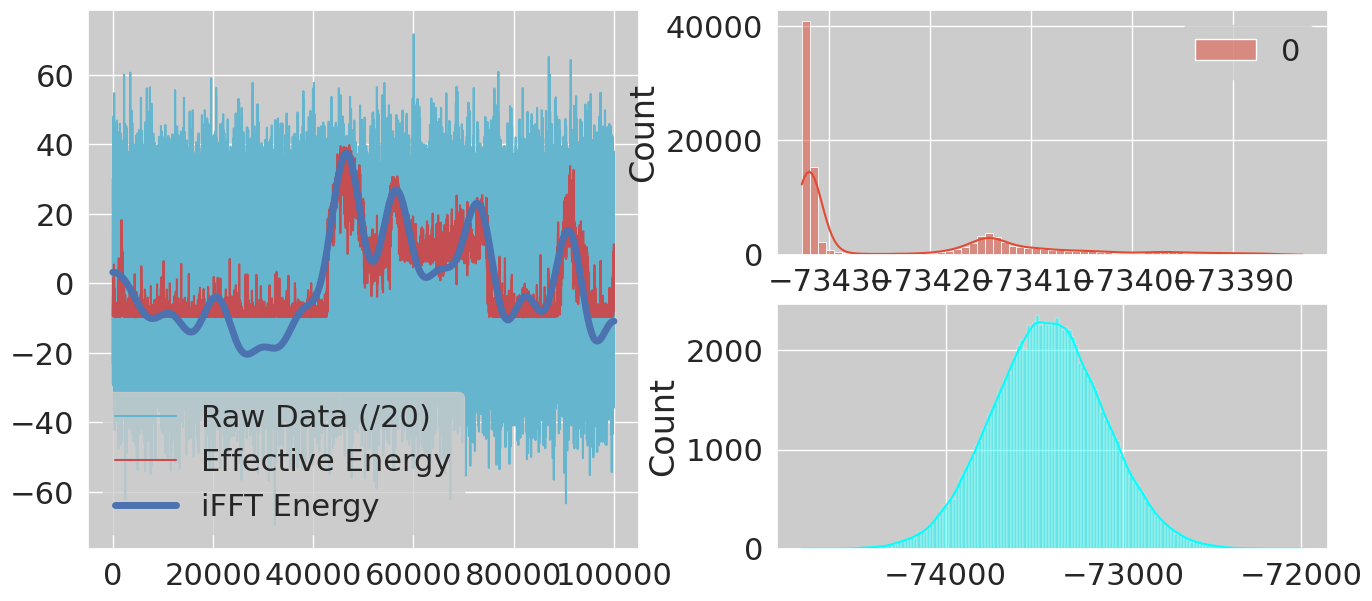

In [15]:
## plot the effective energy
bt.plot.efplot(E0, efft.Ef(kappa), rescl['Ee'])

## Distribution & Free Energy

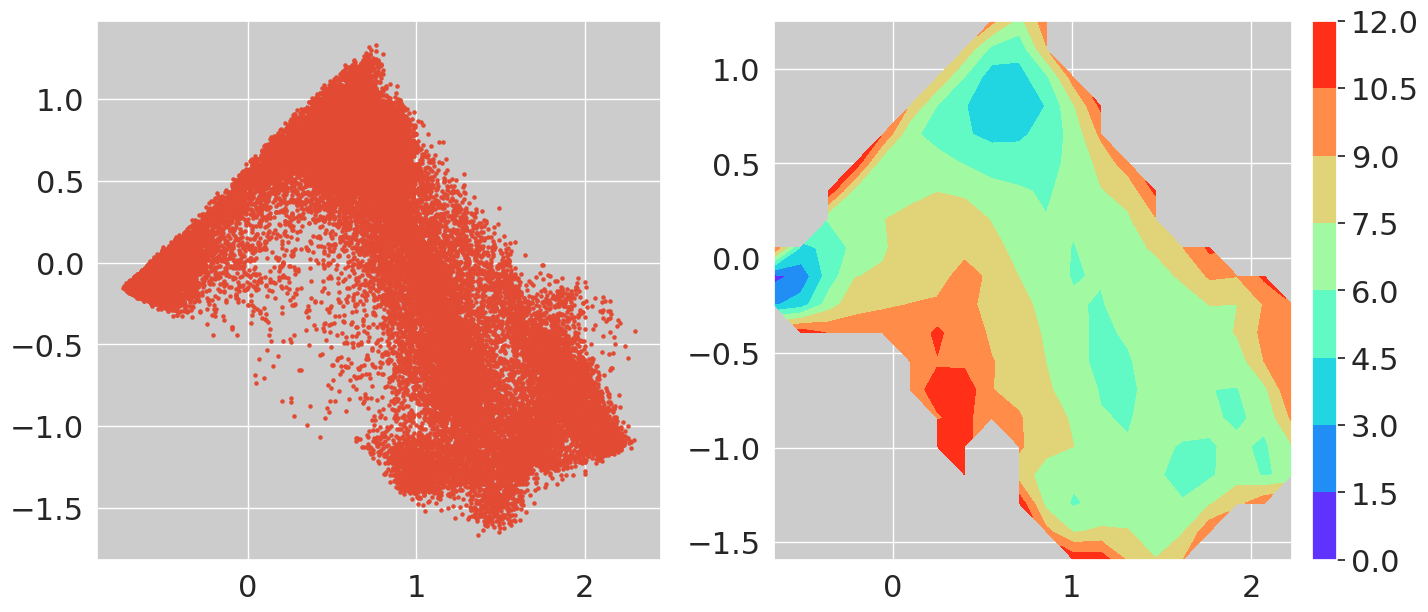

In [16]:
if rescl['X'].shape[1] == 2:
    bt.plot.distr_plot(rescl['X'])
else:
    ## plot by PCA eigen vector
    pca = PCA(n_components = 2)
    bt.plot.distr_plot(pca.fit_transform(rescl['X']))

# Matrix Analysis

## Sample Data

In [17]:
## get the samples
X0s = seg2vec(Xx, step, width)
Xys = seg2vec(rescl['X'], step, width)

## Testing Similarity Matrix

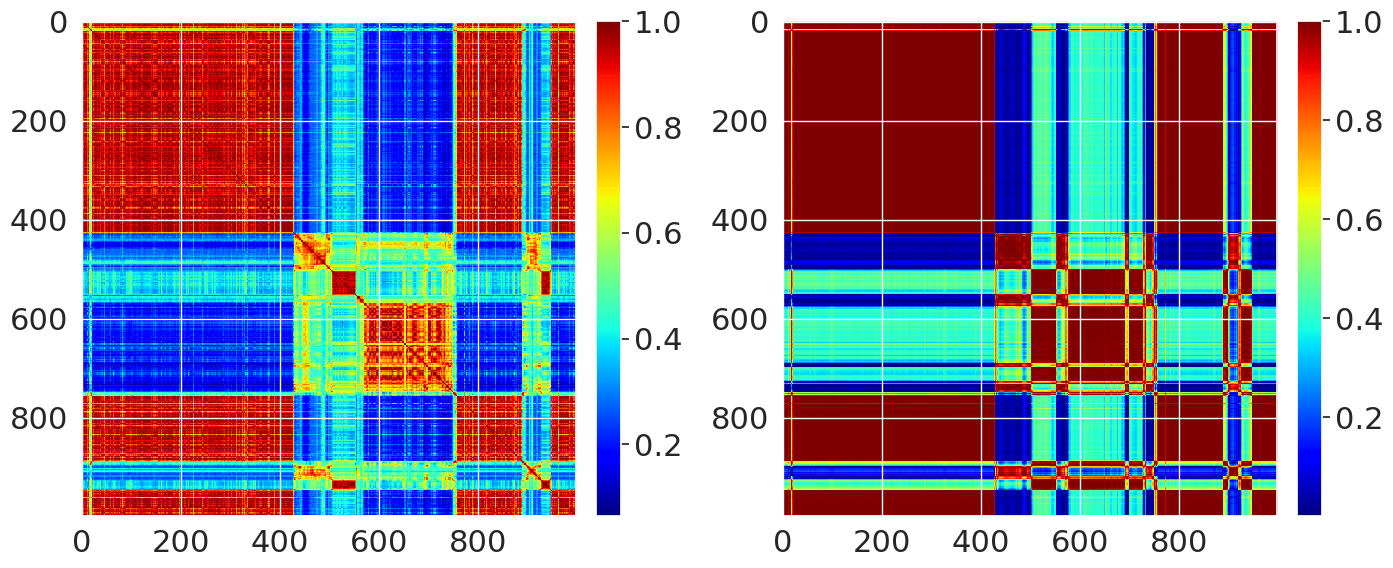

In [18]:
## set distance function and get distance
Smat0  = similar(X0s)
Smaty  = similar(Xys)
    
### plot
fig, axs = plt.subplots(1,2, figsize=(16,32)) 
fig.subplots_adjust(wspace=0.3)
bt.plot.implot(Smat0, axs[0])
bt.plot.implot(Smaty, axs[1])

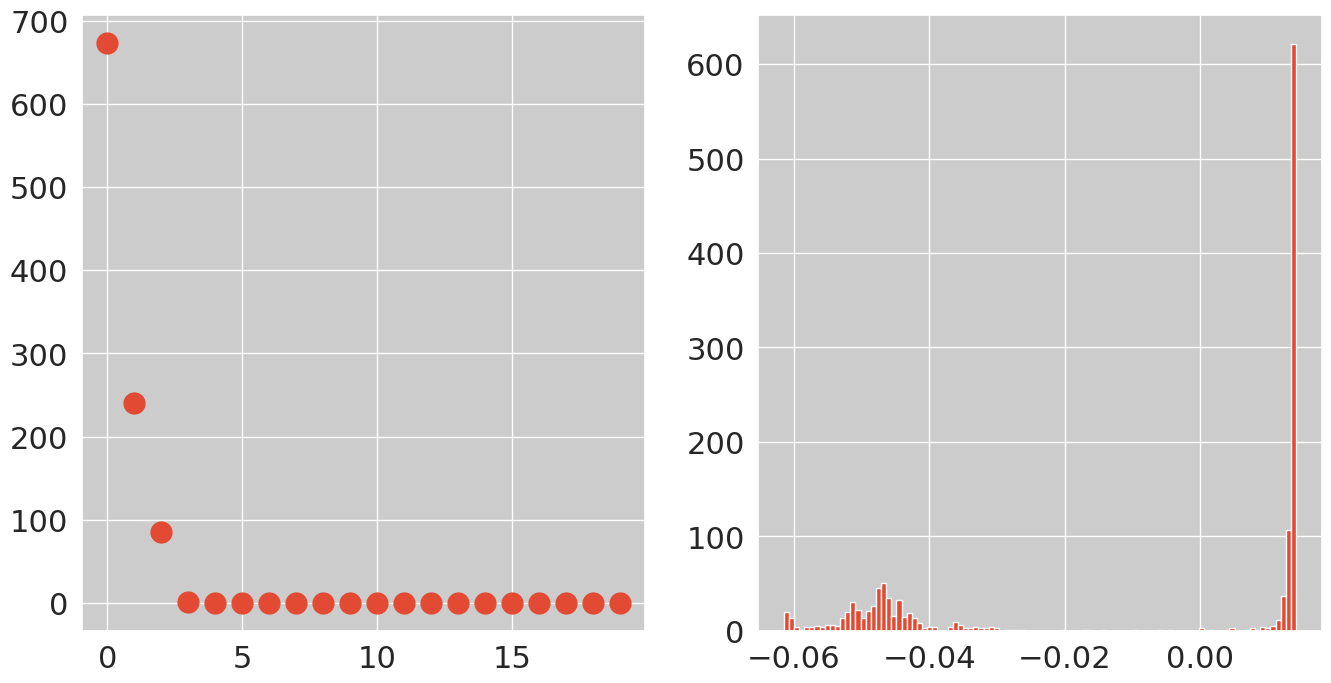

In [19]:
w,v = np.linalg.eig(Smaty)

fig, axs = plt.subplots(1,2, figsize=(16,8)) 
axs[0].plot(w[0:20], "o")
hist = axs[1].hist(v[:,1], bins=100, density=True)

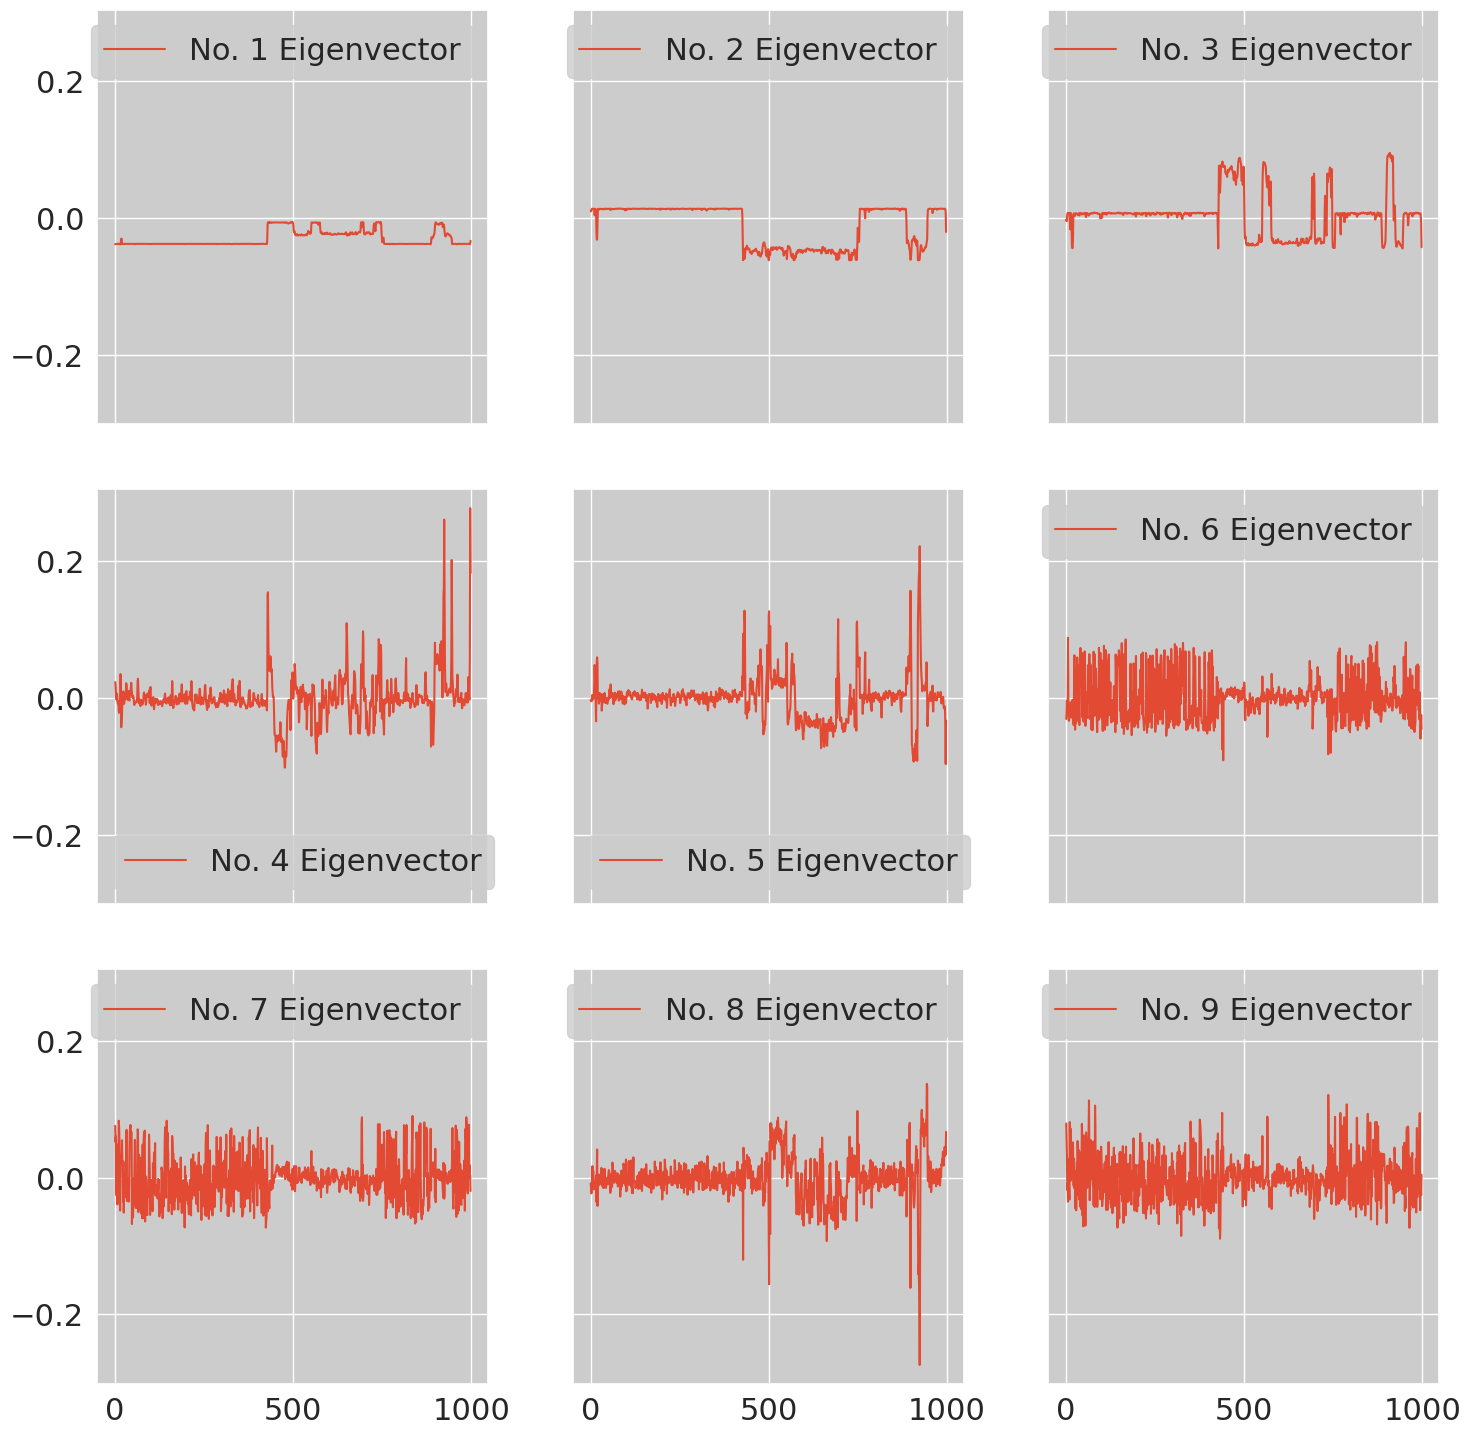

In [20]:
fig, axs = plt.subplots(3,3,sharex=True,sharey=True, figsize=(15,15)) 
sel = range(0,np.size(axs))
fig.tight_layout()
for ax, key in zip(axs.reshape(len(sel)), sel): 
    ax.plot(v[:,key])
    ax.legend(labels =["No. " + str(key+1) + " Eigenvector"])

## Clustering by Kmeans

In [21]:
## Test KMean parameters
def testKMn(n):
    cl = KMeans(n_clusters=n,n_init=50).fit_predict(Xys)
    return evalute(Xys, cl)

score_KMean = pd.DataFrame({'ncluster':np.arange(2,10)})
score_KMean['score'] = score_KMean['ncluster'].apply(testKMn)

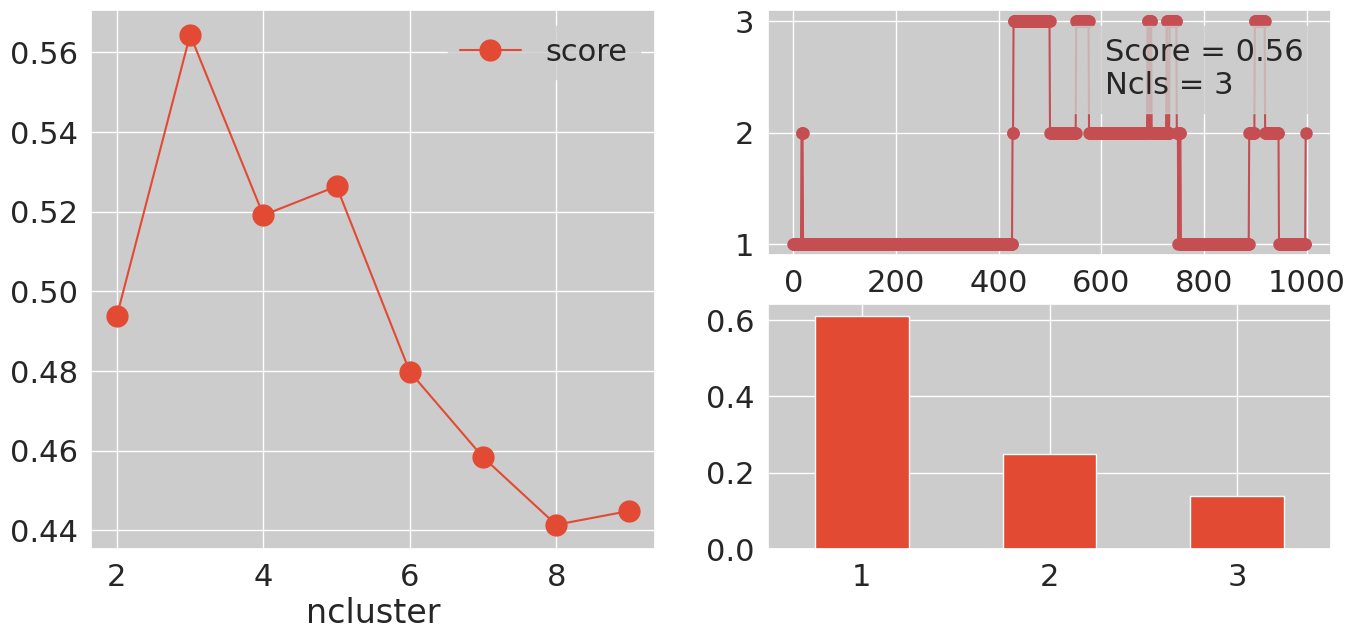

In [22]:
idxPeak = score_KMean['score'].idxmax();
ncls = score_KMean.loc[idxPeak,'ncluster']
cl = KMeans(n_clusters=ncls,n_init=50).fit_predict(Xys)
score = evalute(Xys, cl)

## plot data
lab = "Score = {:.2f}\nNcls = {:d}".format(score, ncls)
bt.plot.clplot(score_KMean.set_index('ncluster'), cl, lab)